# Basic Plotting
In this lesson we will learn to use the plot() method of a pandas.DataFrame to create simple exploratory graphs from tabular data

By the end of this lesson, students will be able to:

- Obtain and interpret preliminary information about a pandas.DataFrame using methods such as `info()` (structure), `describe()` (summary statistics), `nunique()` (unique value counts), `unique()` (distinct values), and `value_counts()` (frequency counts)
  
- Create simple exploratory plots using the plot() method for pandas.DataFrames to visualize trends and distributions
  
- Understand the concept of performing operations on a pandas.DataFrame in-place
  
- Apply method chaining to enable concise and readable code


In [2]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt

# Import data
df = pd.read_csv('../data/wetlands_seasonal_bird_diversity.csv')

# Check data head
df.head()


,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


<Axes: >

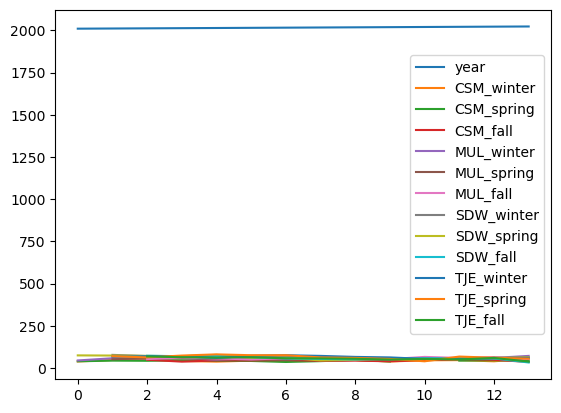

In [3]:
# # Default plot(): one line plot per column with numeric data

df.plot()

## Line Plots

We can make a line plot of one column against another by using the following syntax
df.plot(x='x_values_column', y = 'y_values_column')

<Axes: xlabel='year'>

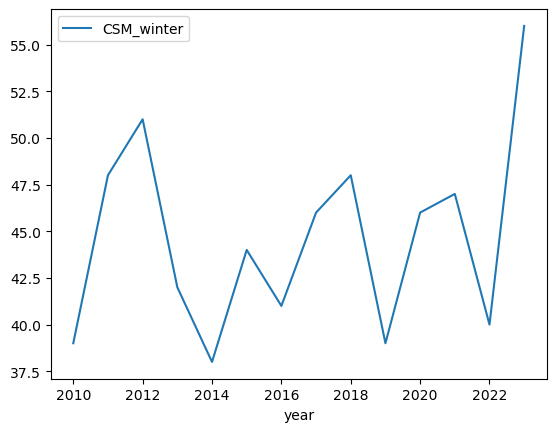

In [4]:
# example

# Bird species registered duirng winter at CSM yearly

df.plot(x = 'year', y = 'CSM_winter')

Basic customization

`title` : title to use for the plot
`xlabel` : name to use for the x-label on the x-axis
`ylable` : name to use for the y-label on the y-axis
`color` : change the color of our plot
`legend` : boolean value True or False (default) includes the legend.
        `False` removes the legend 


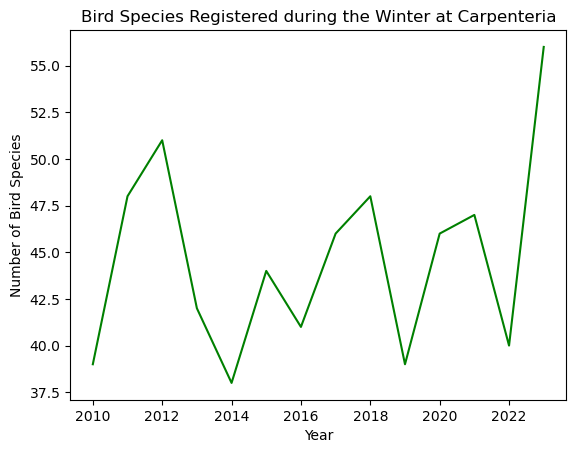

In [5]:
df.plot(x = 'year', 
        y = 'CSM_winter', 
        title = 'Bird Species Registered during the Winter at Carpenteria', 
        xlabel = 'Year', 
        color = 'green',
        ylabel = 'Number of Bird Species', legend = False)

plt.show()

Check IN

Plot a graph of the spring bird surveys at Mugu Lagoon with respect to the years. Include some basic customization.

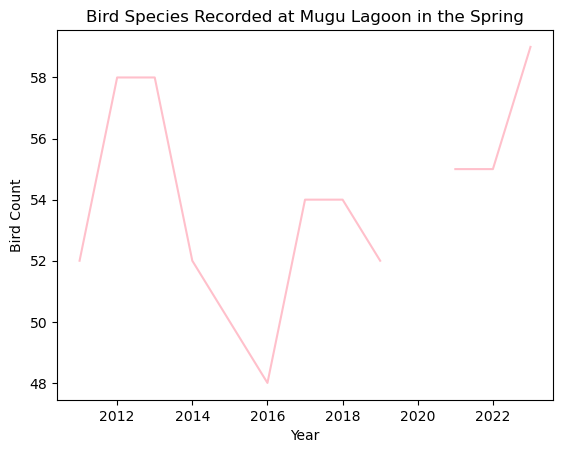

In [6]:
df.plot(x = 'year', y = 'MUL_spring',
       title = 'Bird Species Recorded at Mugu Lagoon in the Spring',
       legend = False,
       xlabel ='Year',
       ylabel = 'Bird Count',
       color = 'pink')

plt.show()

Use the isna() method for pandas.Series and row selection to select the rows in which Mugu Lagoon has NAs during the spring survey

In [7]:
df[df['MUL_spring'].isna()]

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
10,2020,46.0,NaN,47.0,56.0,NaN,66.0,57.0,NaN,58.0,54.0,40.0,54.0


Multiple Line Plots

we can plot multiple line plots by updating these parameters in the plot() method:
y: a list of column names that will be plotted against the x-axis
color: a dictionary {'column_1': 'color_1', 'column_2' : 'color_2'}

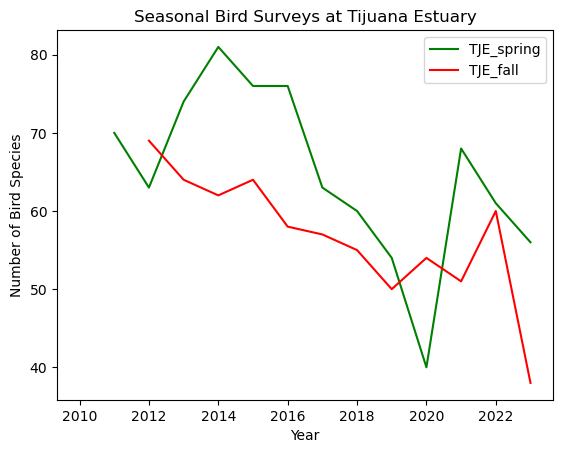

In [8]:
# Example

df.plot(x = 'year', 
        y = ['TJE_spring', 'TJE_fall'],
        title = 'Seasonal Bird Surveys at Tijuana Estuary',
        xlabel = 'Year',
        ylabel = 'Number of Bird Species',
        color = {'TJE_spring' : 'green',
                'TJE_fall' : 'red'},
       )
plt.show()

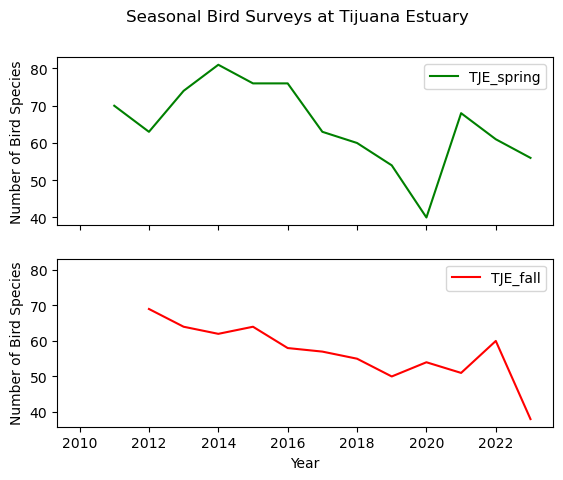

In [9]:
# Example of seperating the plots 

df.plot(x = 'year', 
        y = ['TJE_spring', 'TJE_fall'],
        title = 'Seasonal Bird Surveys at Tijuana Estuary',
        xlabel = 'Year',
        ylabel = 'Number of Bird Species',
        color = {'TJE_spring' : 'green',
                'TJE_fall' : 'red'},
        subplots = True
       );

Updating the Index

to update the index we use the `set_index()` method for a pandas.DataFrame, its general syntax is
`df = df.set_index(new_index)`

where `new_index()` is :
    - the name of the column in the DataFrame df we want to use as the new index
    - if our new index is not a column in the data, an array, or pandas.Series of the same length as our data (we need on index per row)

this operation does not happen in-place: 
    - a function acting in-place means that our original object (in this case a pandas.DataFrame) is modified
    - if the function does not act in-place, a new object (in this case a pandas.DataFrame) is created and the orginal is not modified. 

In [10]:
# If we wanted to update our `df` data frame we could do an explicit assignment to reassign the output of `set_index` to `df()`

# set `column_name` column in df as the new index (reassignment)
# df = df.set_index('column_name')

# or use the inplace parammeter

# set the `column_name` in df as the new index (modify df in place)
# df.set_index('column_name', inplace = True)

In [11]:
# Example
# update the index to be the year column 

df = df.set_index('year')

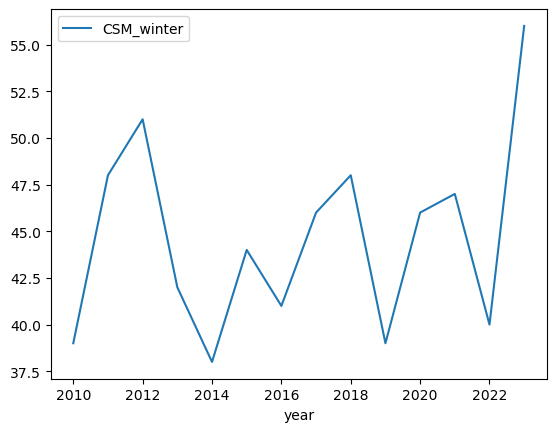

In [12]:
# simple plot of carpenteria salt marsh winter survey

df.plot(y = 'CSM_winter');

In [13]:
# if we need to reset the index to be the number of the rows we can run this
df = df.reset_index()
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


Check IN

In [14]:
# Without running the code, give a step-by-step breakdown of what this code is doing:
# df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

# This code is setting the year to be the index and then selecting all of the rowws a from one column to another and then plotting it. 

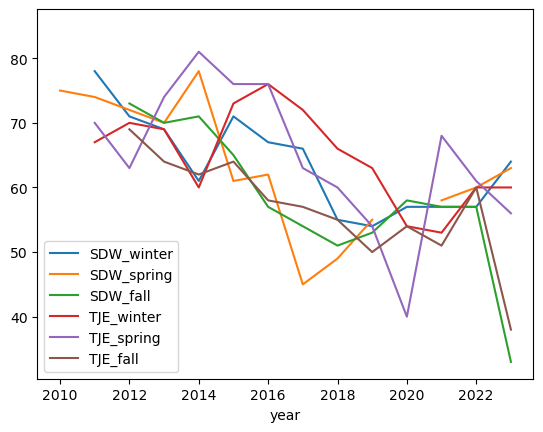

In [15]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot();

Is this code modifying the data frame df? Why or why not?

No, this code is not modifying the dataframe becuase it is not being saved as a new variable. 

Run the code and examine the graph. Review the data description. Do we have all the necessary information to make sure it makes sense to directly compare the surveys at these different sites?

No because there are gaps in the data that may lead to inaccurate conclusions. The recordings also start on different years.

Method Chaining 

<Axes: xlabel='year'>

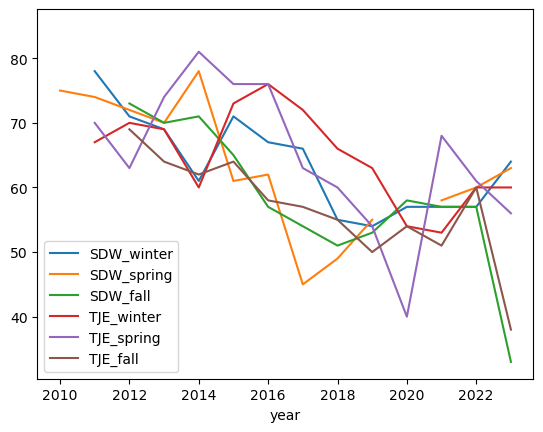

In [16]:
# the code used in the check in is an example of method chaining. Each moethod in the chain returns a new object, 
# allowing the next method to be called directly on the result. 

df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

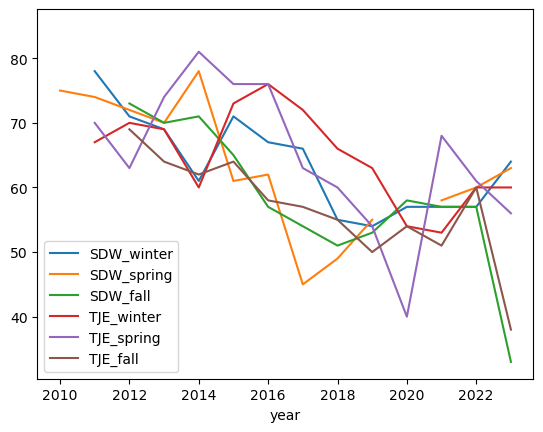

In [17]:
# chaining methods can sometimes get very long so instead we can put them in ()
(df.set_index('year')
    .loc[:,'SDW_winter':'TJE_fall']
    .plot());

<Axes: xlabel='year'>

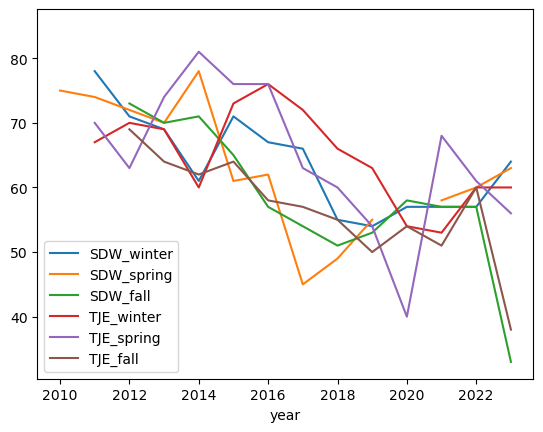

In [18]:
# an alternative method would be to do;

year_index_df = df.set_index('year')
subset_df = year_index_df.loc[:, 'SDW_winter' : 'TJE_fall']
subset_df.plot()

# while this produces the same output, a lot of new variables are created along the way, which can be hard to keep track of.

About the Data

In [19]:
# read in data 
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [20]:
# check column data types and NA values
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [21]:
# simple statistics about numberic columns 
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [22]:
# count the unique values in categorical columns and years
penguins[['species', 'island', 'sex', 'year']].nunique()

species    3
island     3
sex        2
year       3
dtype: int64

In [23]:
# get unique values in species column
penguins['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

In [24]:
# number of values per unique value in species column
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

`kind` argument in `plot()`

At the beginning of the lesson we talked about how the `plot()` method creates a line plot by default. The parameter that controls this behaviour is the `kind` parameter. By changing the value of `kind` we can create different kinds of plots. Let’s look at the documentation to see what these values are:

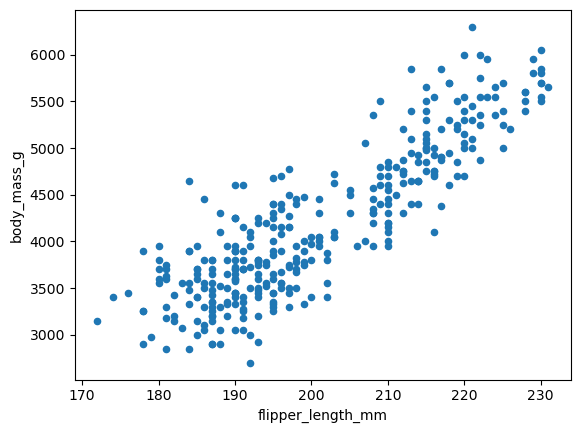

In [25]:
penguins.plot(x = 'flipper_length_mm', y = 'body_mass_g', kind = 'scatter');

<Axes: title={'center': 'Flipper Length and Body Mass for Palmer Penguins'}, xlabel='Flipper Length (mm)', ylabel='Body Mass (g)'>

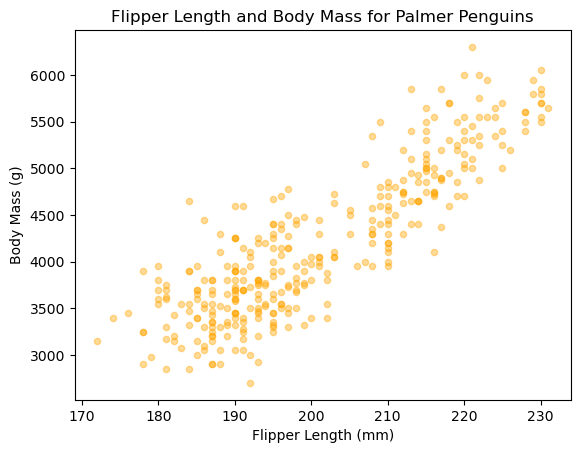

In [26]:
# we can update some other arguments to cutomize the graph. 
penguins.plot(kind = 'scatter',
             x = 'flipper_length_mm',
             y = 'body_mass_g',
              xlabel = 'Flipper Length (mm)',
              ylabel = 'Body Mass (g)',
              title = 'Flipper Length and Body Mass for Palmer Penguins',
              color = 'orange',
              alpha = 0.4
             )

Bar Plots

In [27]:
# we can filter out the 10 smallest penguis with the `.nsmallest(n=x)` function
smallest = penguins['body_mass_g'].nsmallest(10)
smallest

314    2700.0
58     2850.0
64     2850.0
54     2900.0
98     2900.0
116    2900.0
298    2900.0
104    2925.0
47     2975.0
44     3000.0
Name: body_mass_g, dtype: float64

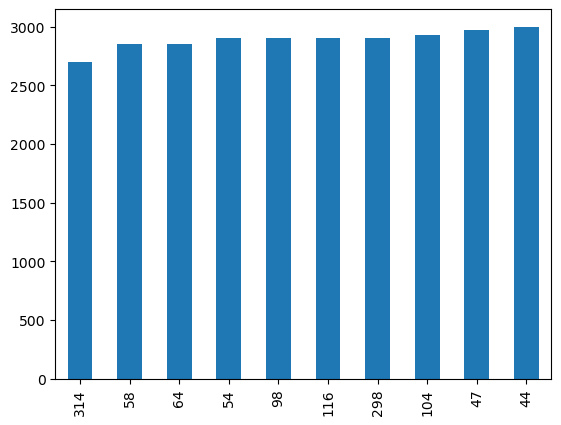

In [28]:
smallest.plot(kind = 'bar');

In [29]:
# if we wanted to look at the other data for these smallest penguins we can use a different call to the `nsmallest` method
penguins.nsmallest(10, 'body_mass_g')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
314,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,female,2008
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,female,2008
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,female,2008
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female,2008
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,female,2009
298,Chinstrap,Dream,43.2,16.6,187.0,2900.0,female,2007
104,Adelie,Biscoe,37.9,18.6,193.0,2925.0,female,2009
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
44,Adelie,Dream,37.0,16.9,185.0,3000.0,female,2007


Histogram

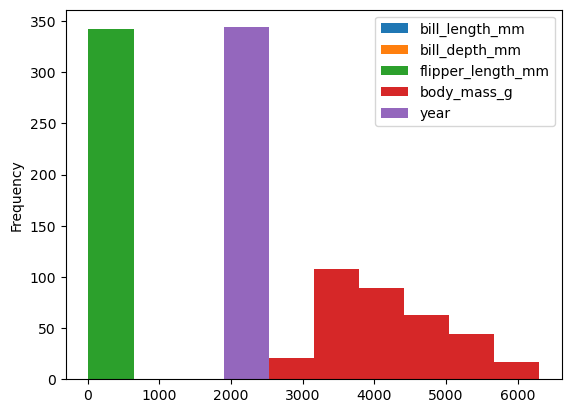

In [30]:
# using plot without subsetting data - a mess again 

penguins.plot(kind= 'hist');

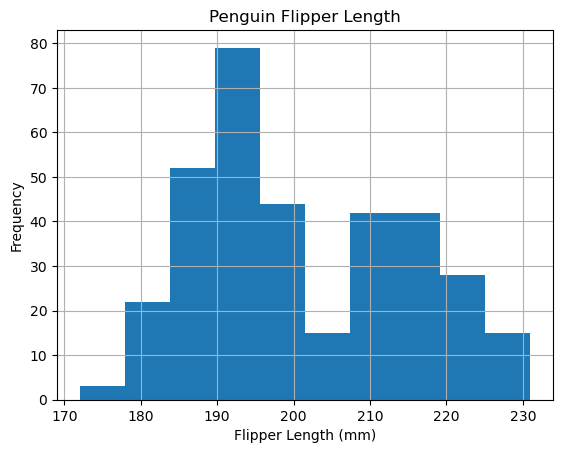

In [31]:
# now lets try it for real 

# distribution of flipper length measuremnts 
# first select data and then plot it

penguins['flipper_length_mm'].plot(
    kind = 'hist',
    title = 'Penguin Flipper Length',
    xlabel = 'Flipper Length (mm)',
    grid = True
);

Check in 

Select the bill_length_mm and bill_depth_mm columns in the penguins data frame and then update the kind parameter to box to make boxplots of the bill length and bill depth.

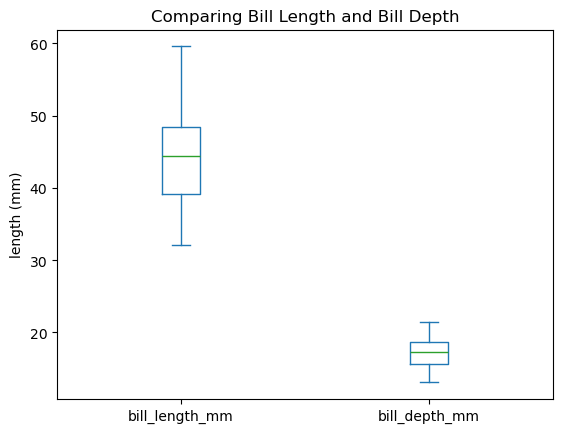

In [32]:
penguins[['bill_length_mm', 'bill_depth_mm']].plot(kind = 'box',
       ylabel = 'length (mm)',
       title = 'Comparing Bill Length and Bill Depth');

Create a simple histogram of the flipper length of female gentoo penguins

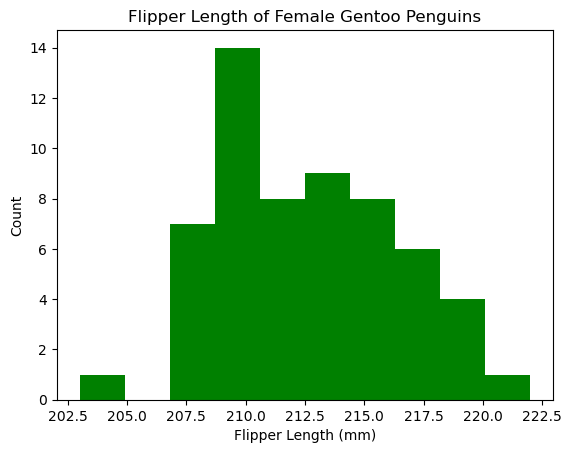

In [33]:
penguins['flipper_length_mm'][penguins['species'] == 'Gentoo'][penguins['sex'] == 'female'].plot(kind = 'hist',
                                   title = 'Flipper Length of Female Gentoo Penguins',
                                   color = 'green',
                                   xlabel = 'Flipper Length (mm)',
                                   ylabel = 'Count');